# Pipeline EHBG-FACS · 03 · NCO supervisado (Attention Model)

**Paradigma 3 — Attention Model entrenado por imitación de un maestro.**

Un **Transformer codificador-decodificador** (Kool/Kwon) entrenado por *teacher forcing* para imitar rutas etiquetadas por un **maestro** (caro): `exact-bc` (óptimo, ignora ventanas) en `nco-sl`, o `aco` (factible) en `nco-sl-feas`. La (in)factibilidad la define el maestro. Inferencia en milisegundos; entrenamiento amortizado en GPU.

In [1]:
# === Configuración del entorno (ejecuta esta celda primero) =================
# Requiere: (a) el paquete `svrplab` (carpeta experiments/colab del repo de tesis)
#           (b) el repo oficial de SVRPBench (se clona solo en bootstrap.init()).
REPO_URL  = "https://github.com/AbrahamHub/TESIS-ANT"   # <-- EDITA si tu repo difiere
USE_DRIVE = True   # persistir banco/resultados/modelos en Google Drive (recomendado)

import os, sys, subprocess

if USE_DRIVE:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception as e:
        print("Drive no disponible (¿ejecutas local?):", e)

def _find_svrplab():
    cands = ["/content/drive/MyDrive/TESIS-ANT/experiments/colab",
             "/content/TESIS-ANT/experiments/colab",
             os.path.join(os.getcwd(), "experiments", "colab"),
             os.getcwd()]
    for c in cands:
        if os.path.isdir(os.path.join(c, "svrplab")):
            return c
    return None

_path = _find_svrplab()
if _path is None:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/content/TESIS-ANT"], check=False)
    _path = "/content/TESIS-ANT/experiments/colab"
sys.path.insert(0, _path)
print("svrplab en:", _path)

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "numpy", "scipy", "pandas",
                "matplotlib", "scikit-learn", "pillow", "tqdm"], check=False)
# torch ya viene en Colab. gurobipy solo se instala en el notebook del paradigma 1.

from svrplab import bootstrap, protocol, data, runner, metrics, viz
env   = bootstrap.init()        # GPU + repo oficial SVRPBench + rutas (Drive si está montado)
proto = protocol.DEFAULT
print("device:", env.device, "| raíz de artefactos:", env.paths.root)

Mounted at /content/drive
svrplab en: /content/TESIS-ANT/experiments/colab
[bootstrap] repo oficial ya presente en /content/drive/MyDrive/EHBG_FACS/svrpbench
[bootstrap] GPU detectada: Tesla T4 (14.6 GB) | torch 2.11.0+cu128 CUDA 12.8
[bootstrap] raíz de artefactos: /content/drive/MyDrive/EHBG_FACS
[bootstrap] results/ figures/ data/ listos | seed=12345 device=cuda
device: cuda | raíz de artefactos: /content/drive/MyDrive/EHBG_FACS


In [2]:
# === Configuración del experimento (IDÉNTICA en los 5 notebooks) ============
# Para garantizar el "piso parejo", TODOS los notebooks deben usar los MISMOS
# SIZES y N_INSTANCES: así resuelven exactamente el mismo banco de instancias.
SIZES       = [10, 20, 50]           # clientes. Extiende a [50,100,200,300] (ver notas).
N_INSTANCES = proto.instances_per_size   # 30 (rigor estadístico). Corrida rápida: pon 5.

bank = data.load_bank(env.paths.instances, SIZES, N_INSTANCES,
                      base_seed=proto.base_seed, capacity_mode=proto.capacity_mode, verbose=True)
print({s: len(v) for s, v in bank.items()}, "instancias por tamaño")

OR-Tools not available: No module named 'ortools'
[data] n=10: 30 instancias (cache) -> bank_n10_m30_s12345_binding.npz
[data] n=20: 30 instancias (cache) -> bank_n20_m30_s12345_binding.npz
[data] n=50: 30 instancias (cache) -> bank_n50_m30_s12345_binding.npz
{10: 30, 20: 30, 50: 30} instancias por tamaño


## Entrenar e inferir (GPU)
Las etiquetas se generan resolviendo instancias de entrenamiento con el maestro (requiere Gurobi si el maestro es `exact-bc`). El modelo se cachea en Drive. Ajusta `epochs`/`n_per_size` según el tiempo disponible.

In [3]:
# Maestro exact-bc requiere Gurobi:
import subprocess, sys; subprocess.run([sys.executable,"-m","pip","install","-q","gurobipy"], check=False)
from svrplab.solvers.nco_sl import NCOSupervised, NCOSupervisedFeasible
import pandas as pd
common = dict(train_sizes=(10,20), n_per_size=256, epochs=80, embed_dim=128,
              device=env.device, models_dir=env.paths.models, verbose=True)
sl      = NCOSupervised(teacher="exact-bc", **common)
sl_feas = NCOSupervisedFeasible(**common)   # maestro = aco (factible)
df_sl   = runner.run_solver(sl,      "nco-sl",      bank, env, proto, verbose=True)
df_feas = runner.run_solver(sl_feas, "nco-sl-feas", bank, env, proto, verbose=True)
df = pd.concat([df_sl, df_feas], ignore_index=True); df

Restricted license - for non-production use only - expires 2027-11-29
[nco-sl] etiquetas (exact-bc): 512 instancias, tamaños [10, 20]
[nco-sl] época 10/80  CE_train=1.4605  CE_val=1.6059
[nco-sl] época 20/80  CE_train=0.7969  CE_val=0.8685
[nco-sl] época 30/80  CE_train=0.6783  CE_val=0.7734
[nco-sl] época 40/80  CE_train=0.6308  CE_val=0.7043
[nco-sl] época 50/80  CE_train=0.5968  CE_val=0.6886
[nco-sl] época 60/80  CE_train=0.5647  CE_val=0.6653
[nco-sl] época 70/80  CE_train=0.5334  CE_val=0.6613
[nco-sl] época 80/80  CE_train=0.5096  CE_val=0.6721
  [nco-sl] n=10 inst=0: E[c]=1902.5 E[c+Q]=2166.3 CVaR=2166.6 feas=0.00 veh=3 t=0.097s (wall 232.5s)
  [nco-sl] n=10 inst=1: E[c]=2297.5 E[c+Q]=5079.7 CVaR=5080.3 feas=0.00 veh=3 t=0.028s (wall 0.1s)
  [nco-sl] n=10 inst=2: E[c]=2618.5 E[c+Q]=3504.5 CVaR=3505.0 feas=0.00 veh=3 t=0.027s (wall 0.1s)
  [nco-sl] n=10 inst=3: E[c]=2316.6 E[c+Q]=3849.7 CVaR=3850.2 feas=0.00 veh=3 t=0.026s (wall 0.1s)
  [nco-sl] n=10 inst=4: E[c]=1933.5 E[c+Q]=4

,solver,paradigm,size,instance,seed,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles
0,nco-sl,3,10,0,22345,NaN,1902.451407,2166.252096,2166.602435,0.0,20.0,0.120721,2.0,0.096572,232.331038,NaN,3
1,nco-sl,3,10,1,22346,NaN,2297.519571,5079.725590,5080.283696,0.0,60.0,0.132521,6.0,0.028474,232.331038,NaN,3
2,nco-sl,3,10,2,22347,NaN,2618.454741,3504.549879,3504.987047,0.0,30.0,0.127811,3.0,0.026502,232.331038,NaN,3
3,nco-sl,3,10,3,22348,NaN,2316.616390,3849.722440,3850.223267,0.0,50.0,0.136740,5.0,0.025713,232.331038,NaN,3
4,nco-sl,3,10,4,22349,NaN,1933.465378,4214.573849,4215.021113,0.0,40.0,0.135117,4.0,0.025876,232.331038,NaN,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,nco-sl-feas,3,50,25,62370,NaN,13074.389662,13415.436254,13416.258458,0.0,12.0,0.304963,6.0,0.208602,572.406163,NaN,22
176,nco-sl-feas,3,50,26,62371,NaN,15406.842551,15762.173270,15762.865868,0.0,8.0,0.286650,4.0,0.233496,572.406163,NaN,24
177,nco-sl-feas,3,50,27,62372,NaN,18013.850877,19724.589178,19725.956686,0.0,26.0,0.306015,13.0,0.216235,572.406163,NaN,23
178,nco-sl-feas,3,50,28,62373,NaN,12510.200569,13223.917259,13238.737470,0.0,14.0,5.782372,7.0,0.202444,572.406163,NaN,20


## Curva de entrenamiento y figuras

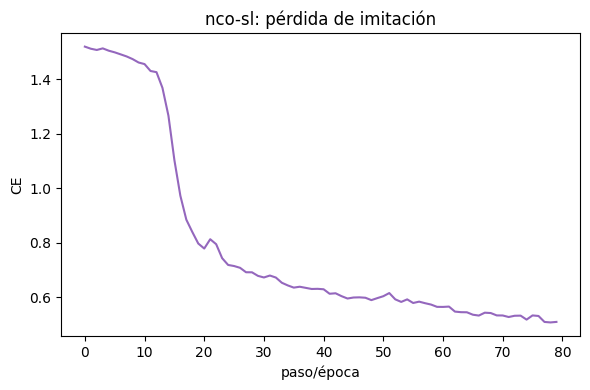

,solver,size,det_cost,expected_cost,expected_total,cvar,feasibility,cvr,robustness,tw_violations,runtime,train_time_s,gap,n_vehicles,expected_cost_std,expected_total_std,cvar_std
0,nco-sl,10,NaN,2339.356333,3597.439110,3598.440867,0.033333,33.665000,0.794526,3.366500,0.030072,232.331038,NaN,3.000000,331.698340,684.244609,684.413665
1,nco-sl,20,NaN,3880.057024,6292.026012,6293.171896,0.000000,32.665000,0.697871,6.533000,0.056148,232.331038,NaN,4.300000,560.587943,925.270554,926.093239
2,nco-sl,50,NaN,7599.637385,14880.427490,14888.637871,0.000000,41.389333,1.929748,20.694667,0.178413,232.331038,NaN,8.700000,884.865650,1575.823661,1580.117483
3,nco-sl-feas,10,NaN,3127.241319,3200.423402,3200.952256,0.433333,9.333333,0.282051,0.933333,0.033862,572.406163,NaN,5.100000,568.863039,600.469675,600.494835
4,nco-sl-feas,20,NaN,6664.467081,6942.623863,6943.154186,0.133333,10.332500,0.458714,2.066500,0.072196,572.406163,NaN,10.266667,1245.819271,1242.164945,1242.196859
5,nco-sl-feas,50,NaN,15869.732665,16643.838257,16646.518283,0.000000,12.466667,1.438480,6.233333,0.219133,572.406163,NaN,24.133333,2418.690001,2554.396368,2554.107168


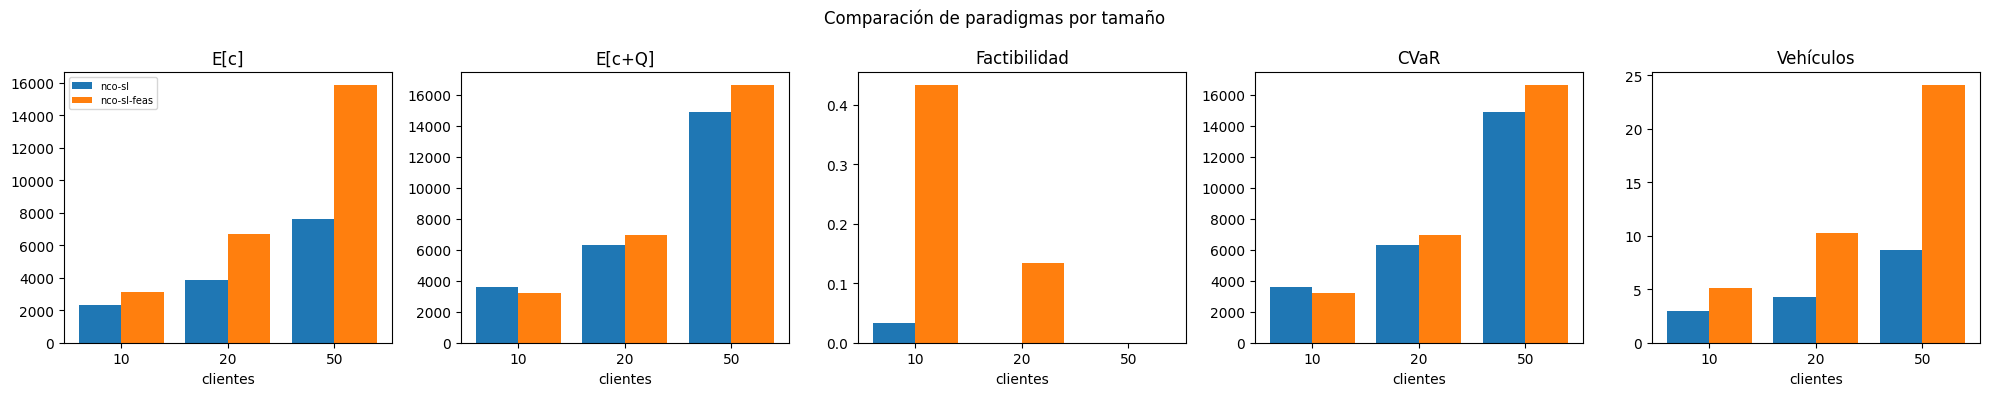

In [4]:
import matplotlib.pyplot as plt
if getattr(sl, "history", None):
    viz.plot_training_curve(sl.history, ylabel="CE", title="nco-sl: pérdida de imitación"); plt.show()
display(metrics.aggregate_by_size(df))
viz.plot_comparison(df); plt.show()

**Interpretación.** `nco-sl` (imita al óptimo) hereda baja factibilidad; `nco-sl-feas` (imita a aco) hereda factibilidad alta — la imitación voraz es **con pérdida**. Confirma que el límite proviene del **maestro**, no del paradigma NCO.